**Import Libraly**

In [42]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



**Read Data**

In [43]:
df = pd.read_csv('E:/Project/FootballerPlayerStatistical/data/results.csv')
df.head()

,Player,Team,Nation,Position,Age,MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,...,Performance_2CrdY,Performance_Fls,Performance_Fld,Performance_Off,Performance_Crs,Performance_Int,Performance_TklW,Performance_PKwon,Performance_PKcon,Performance_OG
0,Aaron Anselmino,Chelsea,ar ARG,DF,19.0,0.0,0,N/a,N/a,N/a,...,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a
1,Aaron Cresswell,West Ham United,eng ENG,DF,34.0,18.0,10,824.0,9.2,0.0,...,0.0,4.0,2.0,0.0,37.0,8.0,8.0,N/a,N/a,0.0
2,Aaron Hickey,Brentford,sct SCO,"DF,MF",22.0,0.0,0,N/a,N/a,N/a,...,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a
3,Aaron Ramsdale,Arsenal,eng ENG,GK,26.0,0.0,0,N/a,N/a,N/a,...,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a,N/a
4,Aaron Ramsdale,Southampton,eng ENG,GK,26.0,N/a,30,2700.0,30.0,0.0,...,0.0,1.0,4.0,0.0,0.0,1.0,0.0,N/a,N/a,0.0


**Chọn cột đặc trưng**

In [44]:
id_cols = ['Player', 'Team', 'Age', 'Nation', 'Position','Playing_Time_Matches','Playing_Time_Starts','Playing_Time_Minutes']
feature_cols = [col for col in df.columns if col not in id_cols]
X_raw = df[feature_cols].copy()

def to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "N/a" or s == "":
        return np.nan
    s = s.replace("%","")
    return pd.to_numeric(s, errors="coerce")

X = X_raw.map(to_num)

keep_cols = X.columns[X.notna().mean() >= 0.6]
X = X[keep_cols]
print("rows:", X.shape[0], "cols:", X.shape[1])

rows: 662 cols: 35


**Impute + Scale**

In [45]:
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imp.fit_transform(X)
X_std = scaler.fit_transform(X_imp)

**Elbow**

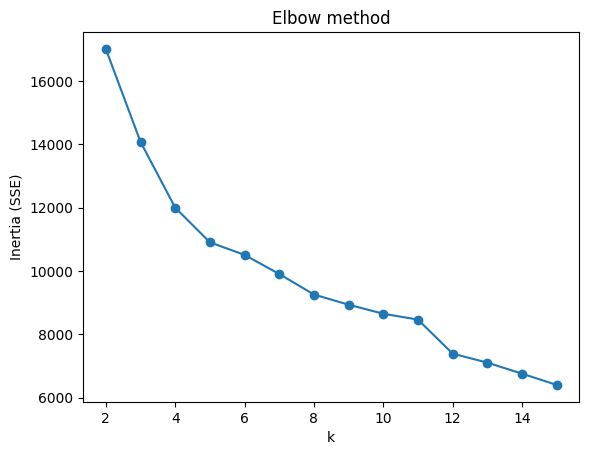

In [46]:
ks = range(2, 16)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_std)
    inertias.append(km.inertia_)

plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow method")
plt.show()

**Train model K-Means**

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_std)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

**Gán nhãn vào cluster gốc**

In [55]:
# Gán nhãn cluster vào dataframe gốc
df['cluster'] = labels

# Thống kê số lượng cầu thủ theo cluster
print("=== Số lượng cầu thủ theo cluster ===")
print(df['cluster'].value_counts().sort_index())
print()


=== Số lượng cầu thủ theo cluster ===
cluster
0     97
1    146
2    407
3     12
Name: count, dtype: int64



In [56]:
df["cluster"] = labels
profile = df.groupby("cluster").mean(numeric_only=True)
print(profile)

         Playing Time_Starts
cluster                     
0                  17.659794
1                  28.109589
2                   4.255528
3                  32.750000


**Vẽ PCA**

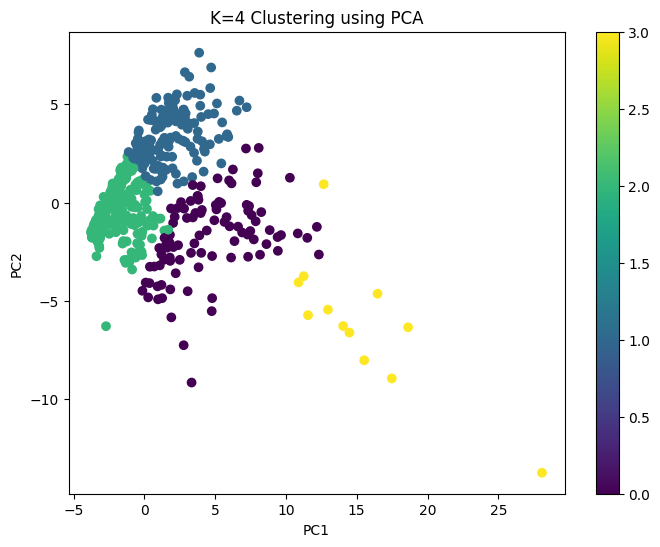

In [57]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K=4 Clustering using PCA")
plt.colorbar()
plt.show()

**Model DBSCAN**

=== DBSCAN result ===
n_clusters: 5
n_noise: 385
cluster sizes (including noise=-1):
{np.int64(-1): np.int64(385), np.int64(0): np.int64(85), np.int64(1): np.int64(146), np.int64(2): np.int64(34), np.int64(3): np.int64(7), np.int64(4): np.int64(5)}
Silhouette (excluding noise): 0.6055090824876044


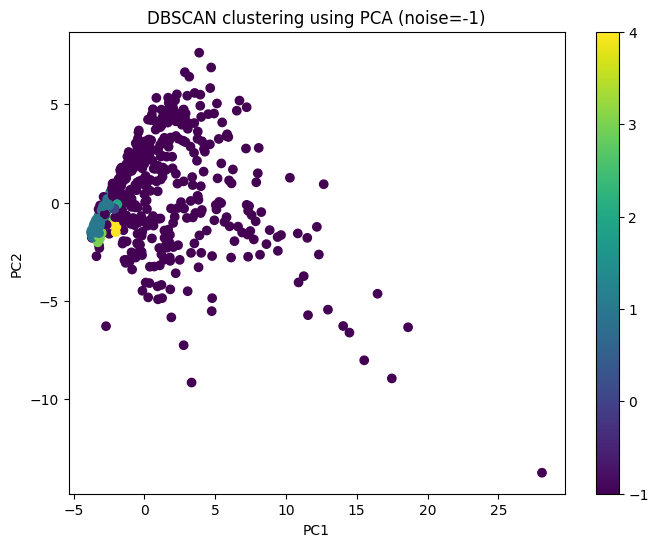

eps = 1.3 {np.int64(-1): np.int64(375), np.int64(0): np.int64(85), np.int64(1): np.int64(148), np.int64(2): np.int64(6), np.int64(3): np.int64(34), np.int64(4): np.int64(7), np.int64(5): np.int64(7)}
eps = 1.4 {np.int64(-1): np.int64(372), np.int64(0): np.int64(119), np.int64(1): np.int64(149), np.int64(2): np.int64(7), np.int64(3): np.int64(8), np.int64(4): np.int64(7)}
eps = 1.5 {np.int64(-1): np.int64(365), np.int64(0): np.int64(272), np.int64(1): np.int64(10), np.int64(2): np.int64(8), np.int64(3): np.int64(7)}
eps = 1.6 {np.int64(-1): np.int64(357), np.int64(0): np.int64(285), np.int64(1): np.int64(9), np.int64(2): np.int64(7), np.int64(3): np.int64(4)}
eps = 1.8 {np.int64(-1): np.int64(320), np.int64(0): np.int64(326), np.int64(1): np.int64(4), np.int64(2): np.int64(7), np.int64(3): np.int64(5)}
eps = 2.0 {np.int64(-1): np.int64(302), np.int64(0): np.int64(352), np.int64(1): np.int64(8)}


In [54]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=1.2, min_samples=5)
labels_db = dbscan.fit_predict(X_std)

# Thống kê số cluster và số điểm noise
n_noise = int((labels_db == -1).sum())
clusters = sorted([c for c in set(labels_db) if c != -1])
n_clusters = len(clusters)

print("=== DBSCAN result ===")
print("n_clusters:", n_clusters)
print("n_noise:", n_noise)
print("cluster sizes (including noise=-1):")
unique, counts = np.unique(labels_db, return_counts=True)
print(dict(zip(unique, counts)))

mask = labels_db != -1
if n_clusters >= 2 and mask.sum() > 1:
    sil_db = silhouette_score(X_std[mask], labels_db[mask])
    print("Silhouette (excluding noise):", sil_db)
else:
    print("Silhouette: N/a (need >= 2 clusters excluding noise)")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title("DBSCAN clustering using PCA (noise=-1)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()
for eps in [1.3, 1.4, 1.5, 1.6, 1.8, 2.0]:
    labels_db = DBSCAN(eps=eps, min_samples=5).fit_predict(X_std)
    unique, counts = np.unique(labels_db, return_counts=True)
    print("eps =", eps, dict(zip(unique, counts)))